In [2]:
import pandas as pd

In [3]:
quotes = pd.read_parquet("results/2025-05-13_quotes.parquet")

# Find periods of sustained short inventory
# What is reservation price vs mid when inventory is negative?
quotes["half_spread"] = (quotes["ask"] - quotes["bid"]) / 2
#quotes['half_spread'].plot()
quotes["mid_ask_dist"] = quotes["ask"] - quotes["mid"]
quotes["mid_bid_dist"] = quotes["mid"] - quotes["bid"]

In [15]:
quotes['mid_ask_dist'].describe()

count    2.521200e+05
mean     6.197131e+02
std      5.876794e+03
min      5.500000e-02
25%      2.850000e-01
50%      3.539500e+01
75%      4.232050e+02
max      1.051575e+06
Name: mid_ask_dist, dtype: float64

In [16]:
quotes['mid_bid_dist'].describe()

count    252120.000000
mean        566.539449
std        5095.157439
min           0.055000
25%           0.275000
50%          33.165000
75%         395.685000
max      908490.195000
Name: mid_bid_dist, dtype: float64

In [7]:
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt

In [18]:
quotes=pd.read_parquet("results/2026-04-14_quotes.parquet")

In [19]:
print(f"kappa: {quotes['kappa'].mean():.4f}")
print(f"sigma: {quotes['sigma'].mean():.8f}")
print(f"spread_bps: {quotes['spread_bps'].mean():.4f}")

kappa: 45.4567
sigma: 0.00002090
spread_bps: 4.7897


In [23]:
import numpy as np

gamma = 0.086
kappa = 45.45
sigma = 0.0000209
T = 3600

inventory_term = gamma * sigma**2 * T
adverse_term = (2/gamma) * np.log(1 + gamma/kappa)
total = inventory_term + adverse_term

print(f"inventory term: {inventory_term * 10000:.6f} bps")
print(f"adverse term:   {adverse_term * 10000:.6f} bps")
print(f"total:          {total * 10000:.6f} bps")

inventory term: 0.001352 bps
adverse term:   439.628206 bps
total:          439.629558 bps


In [12]:
trades = pd.read_parquet("data/trades_btc_synthetic.parquet")

In [16]:
trades.set_index('time_exchange')

,price,size,side
time_exchange,,,
0.021466,101998.907380,0.002453,sell
0.034554,101998.907380,0.004834,sell
0.042757,101998.917380,0.005370,buy
0.049448,101998.917380,0.001016,buy
0.174515,101999.693292,0.001202,sell
...,...,...,...
86399.880279,101106.287075,0.007962,sell
86399.924911,101106.287075,0.002178,sell
86399.932028,101106.287075,0.007711,sell


In [17]:
trades=trades.resample('10s').last()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

In [10]:

trades = pd.read_parquet("data/trades_BTC_2025-05-17.parquet")
trades.head()

,symbol_id,time_exchange,time_coinapi,uuid,price,size,taker_side
0,BINANCE_SPOT_BTC_USDT,2025-05-17 00:00:00.093000+00:00,2025-05-17 00:00:00.325741400+00:00,c943206b-4ce8-4e43-8b75-acd7999feb78,103463.9,0.02811,SELL
1,BINANCE_SPOT_BTC_USDT,2025-05-17 00:00:00.245000+00:00,2025-05-17 00:00:00.326789+00:00,f3366e4a-82fe-4bcf-b2c2-8d2028ecfccc,103463.9,0.00007,SELL
2,BINANCE_SPOT_BTC_USDT,2025-05-17 00:00:00.298000+00:00,2025-05-17 00:00:00.329407400+00:00,03c51156-d2f0-4a28-8f70-e066b6e98b23,103463.9,0.42940,SELL
3,BINANCE_SPOT_BTC_USDT,2025-05-17 00:00:00.298000+00:00,2025-05-17 00:00:00.329479+00:00,e37896a6-abb4-43d4-be2d-e0ad9b627e60,103463.9,0.00005,SELL
4,BINANCE_SPOT_BTC_USDT,2025-05-17 00:00:00.298000+00:00,2025-05-17 00:00:00.329498500+00:00,2d8bc3fa-46a3-4741-9a8c-ccfe8dbe7f68,103463.9,0.00017,SELL


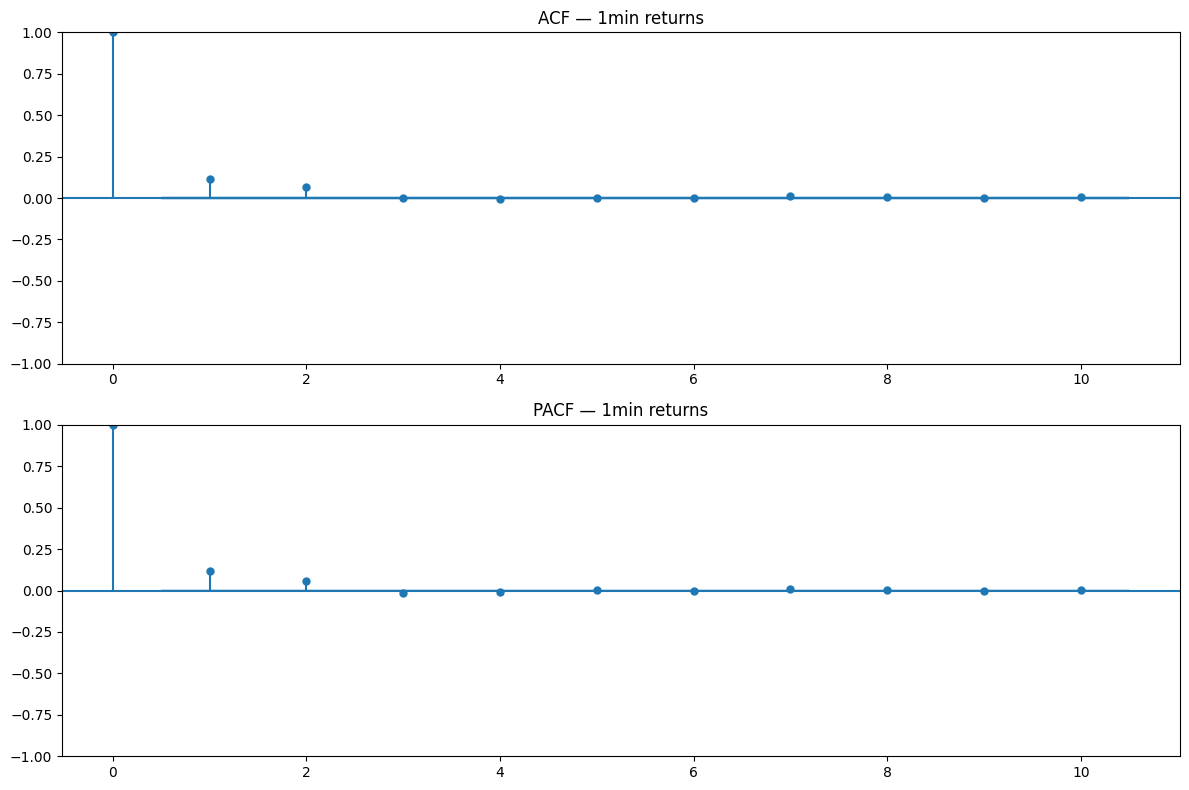

Lag | ACF    | 95% CI
   1 | +0.1151 | [-0.0115, +0.0115]
   2 | +0.0674 | [-0.0117, +0.0117]
   3 | +0.0017 | [-0.0118, +0.0118]
   4 | -0.0037 | [-0.0118, +0.0118]
   5 | +0.0024 | [-0.0118, +0.0118]
   6 | -0.0016 | [-0.0118, +0.0118]
   7 | +0.0112 | [-0.0118, +0.0118]
   8 | +0.0066 | [-0.0118, +0.0118]
   9 | +0.0011 | [-0.0118, +0.0118]
  10 | +0.0063 | [-0.0118, +0.0118]


In [6]:

trades = pd.read_parquet("data/trades_BTC_2025-05-17.parquet")
trades["timestamp"] = pd.to_datetime(trades["time_exchange"], utc=True)
trades = trades.set_index("timestamp").sort_index()

mid = trades["price"].resample("3s").last().ffill()
ret = np.log(mid).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(ret, lags=10, ax=axes[0], title="ACF — 1min returns")
plot_pacf(ret, lags=10, ax=axes[1], title="PACF — 1min returns")
plt.tight_layout()
plt.show()

# Numerical values
acf_vals, confint = acf(ret, nlags=10, alpha=0.05)
print("Lag | ACF    | 95% CI")
for i, (a, ci) in enumerate(zip(acf_vals[1:], confint[1:]), 1):
    print(f"  {i:2d} | {a:+.4f} | [{ci[0]-a:+.4f}, {ci[1]-a:+.4f}]")